In [29]:
!pip install numpy nltk scikit-learn matplotlib
!pip install nltk
!pip install wordcloud

In [53]:
import re, random, math, time, collections, warnings
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

import nltk
for pkg in ('punkt', 'punkt_tab', 'stopwords'):
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('All imports OK')

All imports OK


### Configuration 

In [54]:
CORPUS_PATH = 'cleaned_corpus.txt'   # ← change to your file

# ── Hyperparameter grid ────────────────────────────────────
# (config_name, embed_dim, window_size, n_negatives)
CONFIGS = [
    ('Config-A (dim=50,  win=3, neg=5)',  50,  3,  5),
    ('Config-B (dim=100, win=5, neg=5)', 100,  5,  5),
    ('Config-C (dim=150, win=7, neg=15)',300,  7, 7),
]

EPOCHS          = 30    
LEARNING_RATE   = 0.1
MIN_WORD_COUNT  = 5     # ignore words below this frequency
SUBSAMPLING_T   = 1e-3   # Mikolov subsampling threshold

# Words for Task 3 nearest-neighbour analysis
QUERY_WORDS = ['research', 'student', 'phd', 'exam', 'university']

# Analogy experiments: (pos1, neg1, pos2, description)
# Formula:  pos1 - neg1 + pos2 = ?
ANALOGIES = [
    ('pg',        'ug',       'btech',  'UG:BTech :: PG:?'),
    ('professor', 'student',  'exam',   'student:exam :: professor:?'),
    ('mtech',     'phd',      'thesis', 'PhD:thesis :: MTech:?'),
    ('student',   'research', 'lab',    'research:lab :: student:?'),
]

print('Configuration set.')
print(f'  Corpus     : {CORPUS_PATH}')
print(f'  Epochs     : {EPOCHS}')
print(f'  Configs    : {len(CONFIGS)}')
print(f'  Total runs : {len(CONFIGS) * 2}  (CBOW + Skip-gram each)')

Configuration set.
  Corpus     : cleaned_corpus.txt
  Epochs     : 30
  Configs    : 3
  Total runs : 6  (CBOW + Skip-gram each)


### Corpus Loading & Cleaning

In [56]:
# Words to KEEP even though they appear in NLTK stoplist
DOMAIN_KEEP = {
    'exam', 'research', 'student', 'phd', 'university',
    'professor', 'thesis', 'degree', 'course', 'lecture',
    'paper', 'journal', 'conference', 'lab', 'study',
    'ug', 'pg', 'btech', 'mtech', 'undergraduate',
    'postgraduate', 'program', 'faculty', 'department',
    'semester', 'project', 'grade',
}
STOP = set(stopwords.words('english')) - DOMAIN_KEEP


def clean_and_tokenise(text: str) -> list:
    """Sentence-split -> remove stopwords."""
    corpus = []
    for sent in sent_tokenize(text):
        tokens = [t for t in word_tokenize(sent)
                  if t not in STOP and len(t) >= 2]
        if len(tokens) >= 3:
            corpus.append(tokens)
    return corpus


# ── Load corpus ───────────────────────────────────────────
raw_text = Path("/Users/jahanvigajera/Desktop/Assignment/NLU_assignment/Assignment2/M25CSA012-A2/corpus.txt").read_text(encoding='utf-8', errors='ignore')
corpus   = clean_and_tokenise(raw_text)

all_tokens = [t for s in corpus for t in s]
vocab_set  = set(all_tokens)

print(f'Sentences  : {len(corpus):,}')
print(f'Total tokens: {len(all_tokens):,}')
print(f'Unique tokens: {len(vocab_set):,}')
# print(f'\nSample sentence: {corpus[0]}')


Sentences  : 1
Total tokens: 54,204
Unique tokens: 7,524


In [57]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
with open("/Users/jahanvigajera/Desktop/Assignment/NLU_assignment/Assignment2/problem1/dataset_cleaned_final.txt","r",encoding="utf8") as f:
    text = f.read()
tokens = word_tokenize(text)
print(tokens[:50])

['student', 'wellbeing', 'committee', 'iit', 'jodhpur', 'embark', 'journey', 'aasmaan', 'limitless', 'sky', 'wellbeing', 'newsletter', 'previous', 'next', 'mental', 'health', 'state', 'mental', 'wellbeing', 'enables', 'people', 'cope', 'stresses', 'life', 'realise', 'abilities', 'learn', 'well', 'work', 'well', 'contribute', 'community', 'mental', 'health', 'basic', 'human', 'right', 'crucial', 'personal', 'community', 'socioeconomic', 'development', 'world', 'health', 'organization', 'important', 'physical', 'health', 'connected', 'body']


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/jahanvigajera/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jahanvigajera/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


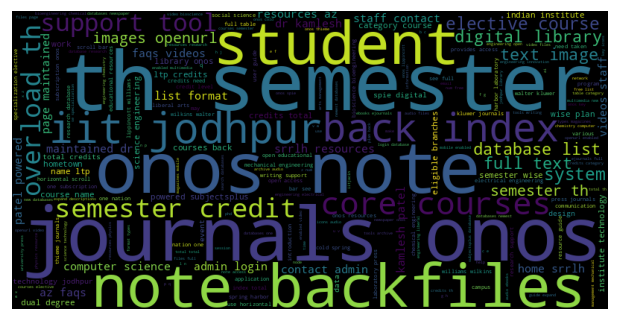

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = " ".join(tokens)

wordcloud = WordCloud(width=800,height=400).generate(all_words)
Path('visualisations_scratch').mkdir(exist_ok=True)
plt.imshow(wordcloud)
plt.savefig('visualisations_scratch/wordcloud.png', dpi=150, bbox_inches='tight')
plt.axis("off")
plt.show()

#### Vocabulary Class (shared by both models)

In [71]:
class Vocabulary:
    """
    Builds word ↔ index mappings and a unigram^(3/4) noise table
    for efficient negative sampling (Mikolov et al., 2013).
    """

    def __init__(self, corpus: list, min_count: int = 1):
        freq = collections.Counter(w for s in corpus for w in s)

        self.word2idx: dict = {}
        self.idx2word: list = []
        self.freq:     list = []

        for word, count in freq.most_common():
            if count >= min_count or word in DOMAIN_KEEP:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)
                self.freq.append(count)

        self.size        = len(self.idx2word)
        self.total_words = sum(self.freq)

        # Unigram^(3/4) noise distribution
        noise = np.array(self.freq, dtype=np.float64) ** 0.75
        self.noise_dist = noise / noise.sum()

        # Pre-built noise table (1M slots) for O(1) sampling
        TABLE_SIZE = 1_000_000
        self.noise_table = np.zeros(TABLE_SIZE, dtype=np.int32)
        idx, cumulative  = 0, self.noise_dist[0]
        for i in range(TABLE_SIZE):
            self.noise_table[i] = idx
            if i / TABLE_SIZE > cumulative and idx < self.size - 1:
                idx       += 1
                cumulative += self.noise_dist[idx]

    def encode(self, sentence: list) -> list:
        return [self.word2idx[w] for w in sentence if w in self.word2idx]

    def negative_sample(self, k: int, exclude: set) -> list:
        """Draw k negatives, never returning an index in `exclude`."""
        samples = []
        while len(samples) < k:
            idx = int(self.noise_table[random.randint(0, len(self.noise_table)-1)])
            if idx not in exclude:
                samples.append(idx)
        return samples


# Build shared vocabulary
vocab = Vocabulary(corpus, min_count=MIN_WORD_COUNT)
print(f'Vocabulary size : {vocab.size:,} words')
print("\nTop 10 words with frequency:")
for i in range(10):
    word = vocab.idx2word[i]
    freq = vocab.freq[i]
    print(f"{word} : {freq}")

Vocabulary size : 2,055 words

Top 10 words with frequency:
onos : 470
engineering : 470
note : 418
semester : 400
journals : 387
research : 370
access : 335
library : 324
th : 300
jodhpur : 293


### Skip-gram Model

In [60]:
class SkipGram:
    """
    Skip-gram with Negative Sampling — pure NumPy.

    Architecture
    ------------
    W_in  (V*D) : target-word embeddings (input matrix)
    W_out (V*D) : context-word embeddings (output matrix)

    For each (target, context) pair:
      1. v_w   = W_in[target]              — target vector
      2. V_ctx = W_out[pos + k negatives]  — output vectors
      3. score = V_ctx @ v_w               — dot products
      4. loss  = BCE(sigmoid(score), label)
      5. backprop + SGD update
    """

    def __init__(self, vocab, embed_dim=100, window=5,
                 n_negative=5, learning_rate=0.025, seed=42):
        self.vocab      = vocab
        self.embed_dim  = embed_dim
        self.window     = window
        self.n_negative = n_negative
        self.lr         = learning_rate
        self.initial_lr = learning_rate
        self.loss_history = []

        rng = np.random.default_rng(seed)
        V, D = vocab.size, embed_dim
        self.W_in  = rng.uniform(-0.5/D, 0.5/D, (V, D)).astype(np.float32)
        self.W_out = np.zeros((V, D), dtype=np.float32)

    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    def _train_pair(self, target_idx: int, context_idx: int) -> float:
        """One SGD step for a single (target, context) pair."""
        # 1. Sample negatives
        negs    = self.vocab.negative_sample(self.n_negative,
                                             {target_idx, context_idx})
        all_ctx = [context_idx] + negs
        labels  = np.array([1] + [0]*self.n_negative, dtype=np.float32)

        # 2. Forward
        v_w    = self.W_in[target_idx]          # (D,)
        V_ctx  = self.W_out[all_ctx]            # (K, D)
        scores = V_ctx @ v_w                    # (K,)
        sigma  = self._sigmoid(scores)

        # 3. Loss  — binary cross-entropy
        eps  = 1e-7
        loss = -np.sum(labels*np.log(sigma+eps) + (1-labels)*np.log(1-sigma+eps))

        # 4. Gradients
        d      = sigma - labels                 # (K,)  ∂L/∂score
        grad_w = V_ctx.T @ d                    # (D,)  → W_in
        grad_c = np.outer(d, v_w)               # (K,D) → W_out

        # 5. SGD update
        self.W_in[target_idx]  -= self.lr * grad_w
        self.W_out[all_ctx]    -= self.lr * grad_c
        return float(loss)

    def train(self, corpus, epochs=5, verbose=True):
        encoded  = [self.vocab.encode(s) for s in corpus]
        total_pairs = sum(2 * self.window * len(s) for s in encoded)

        for epoch in range(1, epochs+1):
            ep_loss, pairs = 0.0, 0
            random.shuffle(encoded)
            for sentence in encoded:
                # Subsampling frequent words
                sentence = [i for i in sentence if random.random() <
                            math.sqrt(SUBSAMPLING_T /
                            (vocab.freq[i]/vocab.total_words + SUBSAMPLING_T))]
                for pos, target in enumerate(sentence):
                    win  = random.randint(1, self.window)
                    ctx  = [sentence[i] for i in
                            range(max(0,pos-win), min(len(sentence),pos+win+1))
                            if i != pos]
                    for context in ctx:
                        ep_loss += self._train_pair(target, context)
                        pairs   += 1
                        if pairs % 10000 == 0:          # LR decay
                            self.lr = max(self.initial_lr*(1-pairs/max(total_pairs*epochs,1)),
                                         self.initial_lr*1e-4)
            avg = ep_loss / max(pairs, 1)
            self.loss_history.append(avg)
            if verbose:
                print(f'  [Skip-gram] Epoch {epoch}/{epochs}  loss={avg:.4f}  lr={self.lr:.6f}')

    # ── Inference ──────────────────────────────────────────
    def get_vector(self, word):
        if word not in self.vocab.word2idx: return None
        return self.W_in[self.vocab.word2idx[word]].copy()

    def _normed(self):
        n = np.linalg.norm(self.W_in, axis=1, keepdims=True) + 1e-10
        return self.W_in / n

    def most_similar(self, word, topn=5):
        W = self._normed()
        idx  = self.vocab.word2idx[word]
        sims = W @ W[idx]; sims[idx] = -1
        top  = np.argsort(sims)[::-1][:topn]
        return [(self.vocab.idx2word[i], float(sims[i])) for i in top]

    def analogy(self, pos1, neg1, pos2, topn=5):
        W = self._normed()
        q = W[self.vocab.word2idx[pos1]] - W[self.vocab.word2idx[neg1]] + W[self.vocab.word2idx[pos2]]
        q /= np.linalg.norm(q) + 1e-10
        sims = W @ q
        for w in (pos1, neg1, pos2): sims[self.vocab.word2idx[w]] = -1
        top = np.argsort(sims)[::-1][:topn]
        return [(self.vocab.idx2word[i], float(sims[i])) for i in top]

    def cosine_similarity(self, w1, w2):
        v1, v2 = self.get_vector(w1), self.get_vector(w2)
        return float(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)+1e-10))


print('SkipGram class defined.')

SkipGram class defined.


### CBOW Model

In [61]:
class CBOW:
    """
    CBOW with Negative Sampling — pure NumPy.

    Architecture
    ------------
    W_in  (V*D) : context-word embeddings
    W_out (V*D) : target-word embeddings

    Key difference from Skip-gram:
      h = MEAN( W_in[context_words] )   ← mean-pool, not individual lookups
      Then predict the centre word from h using the same BCE+negative-sampling loss.
      Gradient flows back equally to every context word (divided by C).
    """

    def __init__(self, vocab, embed_dim=100, window=5,
                 n_negative=5, learning_rate=0.025, seed=42):
        self.vocab      = vocab
        self.embed_dim  = embed_dim
        self.window     = window
        self.n_negative = n_negative
        self.lr         = learning_rate
        self.initial_lr = learning_rate
        self.loss_history = []

        rng = np.random.default_rng(seed)
        V, D = vocab.size, embed_dim
        self.W_in  = rng.uniform(-0.5/D, 0.5/D, (V, D)).astype(np.float32)
        self.W_out = np.zeros((V, D), dtype=np.float32)

    @staticmethod
    def _sigmoid(x):
        return np.where(x >= 0,
                        1.0 / (1.0 + np.exp(-x)),
                        np.exp(x) / (1.0 + np.exp(x)))

    def _train_window(self, context_indices: list, target_idx: int) -> float:
        """One SGD step for a CBOW window."""
        if not context_indices: return 0.0

        # 1. Sample negatives
        negs    = self.vocab.negative_sample(self.n_negative,
                                             set(context_indices)|{target_idx})
        all_ctx = [target_idx] + negs
        labels  = np.array([1]+[0]*self.n_negative, dtype=np.float32)

        # 2. Forward — mean-pool context embeddings
        ctx_vecs = self.W_in[context_indices]   # (C, D)
        h        = ctx_vecs.mean(axis=0)        # (D,)  ← THE key CBOW step
        V_out    = self.W_out[all_ctx]          # (K, D)
        scores   = V_out @ h                   # (K,)
        sigma    = self._sigmoid(scores)

        # 3. Loss
        eps  = 1e-7
        loss = -np.sum(labels*np.log(sigma+eps) + (1-labels)*np.log(1-sigma+eps))

        # 4. Gradients
        d      = sigma - labels                 # (K,)
        grad_h = V_out.T @ d                    # (D,)  gradient w.r.t. h
        C      = len(context_indices)
        grad_c = grad_h / C                     # (D,)  shared across context words  ← 1/C factor
        grad_out = np.outer(d, h)               # (K, D)

        # 5. SGD update
        for ci in context_indices:
            self.W_in[ci]      -= self.lr * grad_c
        self.W_out[all_ctx]    -= self.lr * grad_out
        return float(loss)

    def train(self, corpus, epochs=5, verbose=True):
        encoded = [self.vocab.encode(s) for s in corpus]
        total   = sum(len(s) for s in encoded)

        for epoch in range(1, epochs+1):
            ep_loss, wins = 0.0, 0
            random.shuffle(encoded)
            for sentence in encoded:
                sentence = [i for i in sentence if random.random() <
                            math.sqrt(SUBSAMPLING_T /
                            (vocab.freq[i]/vocab.total_words + SUBSAMPLING_T))]
                for pos, target in enumerate(sentence):
                    win  = random.randint(1, self.window)
                    ctx  = [sentence[i] for i in
                            range(max(0,pos-win), min(len(sentence),pos+win+1))
                            if i != pos]
                    if not ctx: continue
                    ep_loss += self._train_window(ctx, target)
                    wins    += 1
                    if wins % 10000 == 0:
                        self.lr = max(self.initial_lr*(1-wins/max(total*epochs,1)),
                                     self.initial_lr*1e-4)
            avg = ep_loss / max(wins, 1)
            self.loss_history.append(avg)
            if verbose:
                print(f'  [CBOW]      Epoch {epoch}/{epochs}  loss={avg:.4f}  lr={self.lr:.6f}')

    # ── Inference (same interface as SkipGram) ─────────────
    def get_vector(self, word):
        if word not in self.vocab.word2idx: return None
        return self.W_in[self.vocab.word2idx[word]].copy()

    def _normed(self):
        n = np.linalg.norm(self.W_in, axis=1, keepdims=True) + 1e-10
        return self.W_in / n

    def most_similar(self, word, topn=5):
        W = self._normed()
        idx  = self.vocab.word2idx[word]
        sims = W @ W[idx]; sims[idx] = -1
        top  = np.argsort(sims)[::-1][:topn]
        return [(self.vocab.idx2word[i], float(sims[i])) for i in top]

    def analogy(self, pos1, neg1, pos2, topn=5):
        W = self._normed()
        q = W[self.vocab.word2idx[pos1]] - W[self.vocab.word2idx[neg1]] + W[self.vocab.word2idx[pos2]]
        q /= np.linalg.norm(q) + 1e-10
        sims = W @ q
        for w in (pos1,neg1,pos2): sims[self.vocab.word2idx[w]] = -1
        top = np.argsort(sims)[::-1][:topn]
        return [(self.vocab.idx2word[i], float(sims[i])) for i in top]

    def cosine_similarity(self, w1, w2):
        v1, v2 = self.get_vector(w1), self.get_vector(w2)
        return float(np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2)+1e-10))


print('CBOW class defined.')

CBOW class defined.


#### Train All 6 Model Variants

In [38]:
trained_models = {}   # key: run_name  → model object
results_table  = []   # for summary display

for cfg_name, dim, win, neg in CONFIGS:
    for arch, ModelClass in [('CBOW', CBOW), ('Skip-gram', SkipGram)]:
        run_name = f'{arch} | {cfg_name}'
        print(f'\n▶ Training: {run_name}')

        model = ModelClass(
            vocab        = vocab,
            embed_dim    = dim,
            window       = win,
            n_negative   = neg,
            learning_rate= LEARNING_RATE,
        )
        t0 = time.time()
        model.train(corpus, epochs=EPOCHS, verbose=True)
        elapsed = time.time() - t0

        trained_models[run_name] = model
        results_table.append({
            'Architecture': arch,
            'Config'       : cfg_name,
            'Dim'          : dim,
            'Window'       : win,
            'Negatives'    : neg,
            'Final Loss'   : round(model.loss_history[-1], 4),
            'Time (s)'     : round(elapsed, 2),
        })

print('\n' + '='*70)
print('TASK 2 — TRAINING SUMMARY')
print('='*70)
print(f'{"Architecture":<12} {"Config":<38} {"Dim":>5} {"Win":>5} {"Neg":>5} {"Loss":>8} {"Time(s)":>9}')
print('-'*70)
for r in results_table:
    print(f'{r["Architecture"]:<12} {r["Config"]:<38} {r["Dim"]:>5} {r["Window"]:>5} '
          f'{r["Negatives"]:>5} {r["Final Loss"]:>8} {r["Time (s)"]:>9}')


▶ Training: CBOW | Config-A (dim=50,  win=3, neg=5)
  [CBOW]      Epoch 1/30  loss=3.9924  lr=0.097779
  [CBOW]      Epoch 2/30  loss=2.8882  lr=0.097779
  [CBOW]      Epoch 3/30  loss=2.5273  lr=0.097779
  [CBOW]      Epoch 4/30  loss=2.2719  lr=0.097779
  [CBOW]      Epoch 5/30  loss=2.0799  lr=0.097779
  [CBOW]      Epoch 6/30  loss=1.9065  lr=0.097779
  [CBOW]      Epoch 7/30  loss=1.7530  lr=0.097779
  [CBOW]      Epoch 8/30  loss=1.5919  lr=0.097779
  [CBOW]      Epoch 9/30  loss=1.4780  lr=0.097779
  [CBOW]      Epoch 10/30  loss=1.3592  lr=0.097779
  [CBOW]      Epoch 11/30  loss=1.2552  lr=0.097779
  [CBOW]      Epoch 12/30  loss=1.1729  lr=0.097779
  [CBOW]      Epoch 13/30  loss=1.1011  lr=0.097779
  [CBOW]      Epoch 14/30  loss=1.0502  lr=0.097779
  [CBOW]      Epoch 15/30  loss=0.9928  lr=0.097779
  [CBOW]      Epoch 16/30  loss=0.9390  lr=0.097779
  [CBOW]      Epoch 17/30  loss=0.8941  lr=0.097779
  [CBOW]      Epoch 18/30  loss=0.8614  lr=0.097779
  [CBOW]      Epoch 

#### Training Loss Curves

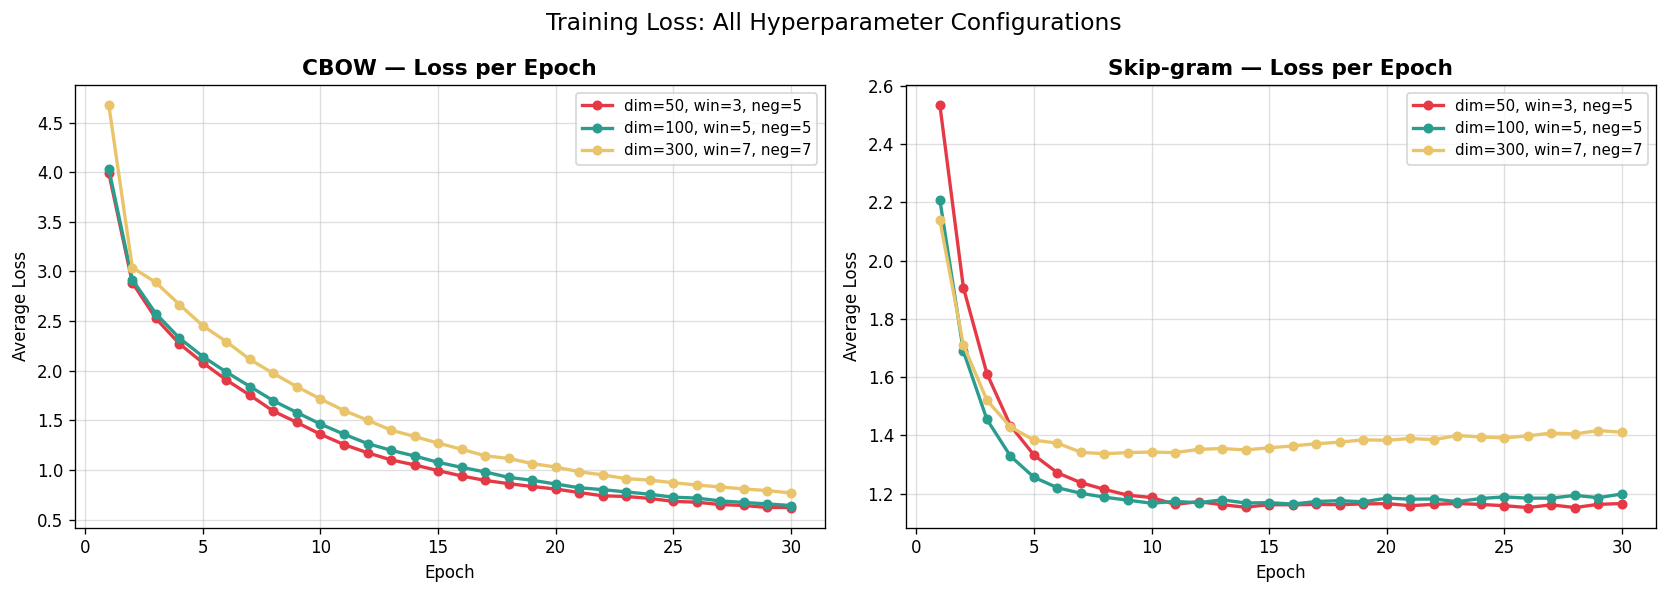

Saved: visualisations_scratch/loss_curves.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E63946', '#2A9D8F', '#E9C46A']

for ax, arch in zip(axes, ['CBOW', 'Skip-gram']):
    for (cfg_name, dim, win, neg), color in zip(CONFIGS, colors):
        run_name = f'{arch} | {cfg_name}'
        m = trained_models[run_name]
        ax.plot(range(1, len(m.loss_history)+1), m.loss_history,
                'o-', label=f'dim={dim}, win={win}, neg={neg}',
                color=color, linewidth=2, markersize=5)
    ax.set_title(f'{arch} — Loss per Epoch', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Average Loss')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.4)

plt.suptitle('Training Loss: All Hyperparameter Configurations', fontsize=14)
plt.tight_layout()
plt.savefig('visualisations_scratch/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualisations_scratch/loss_curves.png')

### Top-5 Nearest Neighbours
Using **Config-B** (dim=100, win=5, neg=5) — the standard baseline.

In [40]:
print("Available keys in trained_models:")
for key in trained_models.keys():
    print(f"'{key}'")

Available keys in trained_models:
'CBOW | Config-A (dim=50,  win=3, neg=5)'
'Skip-gram | Config-A (dim=50,  win=3, neg=5)'
'CBOW | Config-B (dim=100, win=5, neg=5)'
'Skip-gram | Config-B (dim=100, win=5, neg=5)'
'CBOW | Config-C (dim=150, win=7, neg=15)'
'Skip-gram | Config-C (dim=150, win=7, neg=15)'


In [50]:
BEST_CBOW = 'CBOW | Config-A (dim=50,  win=3, neg=5)'
BEST_SG   = 'Skip-gram | Config-A (dim=50,  win=3, neg=5)'

def print_neighbours(model, model_name):
    vocab_set = set(model.vocab.word2idx)
    print(f'\n{"="*60}')
    print(f'  TOP-5 NEAREST NEIGHBOURS — {model_name}')
    print(f'{"="*60}')
    print(f'  {"Word":<14} {"Rank":<6} {"Neighbour":<18} {"Cosine Sim":>10}')
    print('  ' + '-'*50)
    for word in QUERY_WORDS:
        if word not in vocab_set:
            print(f'  {word:<14} [NOT IN VOCABULARY]')
            continue
        nbrs = model.most_similar(word, topn=5)
        for rank, (nbr, score) in enumerate(nbrs, 1):
            label = word if rank == 1 else ''
            print(f'  {label:<14} {rank:<6} {nbr:<18} {score:>10.4f}')
        print()


print_neighbours(trained_models[BEST_CBOW], 'CBOW')
print_neighbours(trained_models[BEST_SG],   'Skip-gram')


  TOP-5 NEAREST NEIGHBOURS — CBOW
  Word           Rank   Neighbour          Cosine Sim
  --------------------------------------------------
  research       1      governments            0.6251
                 2      outstanding            0.5816
                 3      notforprofit           0.5778
                 4      corequisite            0.5778
                 5      paper                  0.5522

  student        1      every                  0.6121
                 2      heads                  0.5749
                 3      experiences            0.5672
                 4      needs                  0.5621
                 5      fests                  0.5561

  phd            1      amit                   0.6499
                 2      prof                   0.6418
                 3      graduate               0.6086
                 4      bombay                 0.5918
                 5      postdoctoral           0.5908

  exam           1      admission            

### Analogy Experiments

In [42]:
def run_analogies(model, model_name):
    vocab_set = set(model.vocab.word2idx)
    print(f'\n{"="*65}')
    print(f'  ANALOGY EXPERIMENTS — {model_name}')
    print(f'  Formula: a - b + c = ?')
    print(f'{"="*65}')
    print(f'  {"Analogy":<35} {"Rank":<5} {"Prediction":<18} {"Score":>8}  Meaningful?')
    print('  ' + '-'*65)

    for pos1, neg1, pos2, desc in ANALOGIES:
        missing = [w for w in (pos1, neg1, pos2) if w not in vocab_set]
        if missing:
            print(f'  {desc:<35} [OOV: {", ".join(missing)}]')
            continue
        try:
            results = model.analogy(pos1, neg1, pos2, topn=3)
            for i, (word, score) in enumerate(results):
                label = desc if i == 0 else ''
                rank  = i + 1
                flag  = ('✓ yes' if score > 0.55 else
                         '~ maybe' if score > 0.35 else '✗ weak') if i == 0 else ''
                print(f'  {label:<35} {rank:<5} {word:<18} {score:>8.4f}  {flag}')
            print()
        except Exception as e:
            print(f'  {desc:<35} ERROR: {e}\n')


run_analogies(trained_models[BEST_CBOW], 'CBOW')
run_analogies(trained_models[BEST_SG],   'Skip-gram')


  ANALOGY EXPERIMENTS — CBOW
  Formula: a - b + c = ?
  Analogy                             Rank  Prediction            Score  Meaningful?
  -----------------------------------------------------------------
  UG:BTech :: PG:?                    1     mba                  0.6017  ✓ yes
                                      2     dcs                  0.5976  
                                      3     awarded              0.5871  

  student:exam :: professor:?         1     msc                  0.5524  ✓ yes
                                      2     solidworks           0.5443  
                                      3     junior               0.5330  

  PhD:thesis :: MTech:?               1     curriculum           0.5917  ✓ yes
                                      2     electives            0.5748  
                                      3     mo                   0.5499  

  research:lab :: student:?           1     team                 0.4907  ~ maybe
                           

### Cross-Model Cosine Similarity Comparison

In [43]:
word_pairs = [
    ('research', 'lab'),
    ('student',  'exam'),
    ('phd',      'thesis'),
    ('btech',    'ug'),
    ('professor','faculty'),
]

print('\nCosine Similarity Comparison: CBOW vs Skip-gram')
print(f'{"Word Pair":<30} {"CBOW":>8} {"Skip-gram":>10}  Closer')
print('-'*55)

cbow_m = trained_models[BEST_CBOW]
sg_m   = trained_models[BEST_SG]
vset_c = set(cbow_m.vocab.word2idx)
vset_s = set(sg_m.vocab.word2idx)

for w1, w2 in word_pairs:
    pair_str = f'({w1}, {w2})'
    if w1 not in vset_c or w2 not in vset_c:
        print(f'{pair_str:<30} [OOV in CBOW]')
        continue
    if w1 not in vset_s or w2 not in vset_s:
        print(f'{pair_str:<30} [OOV in Skip-gram]')
        continue
    sc = cbow_m.cosine_similarity(w1, w2)
    ss = sg_m.cosine_similarity(w1, w2)
    winner = 'CBOW' if sc > ss else 'Skip-gram'
    print(f'{pair_str:<30} {sc:>8.4f} {ss:>10.4f}  {winner}')


Cosine Similarity Comparison: CBOW vs Skip-gram
Word Pair                          CBOW  Skip-gram  Closer
-------------------------------------------------------
(research, lab)                  0.2056     0.2257  Skip-gram
(student, exam)                 -0.0332     0.2166  Skip-gram
(phd, thesis)                    0.4944     0.5521  Skip-gram
(btech, ug)                      0.2851     0.1927  CBOW
(professor, faculty)             0.3774     0.3200  CBOW


### PCA Visualisation

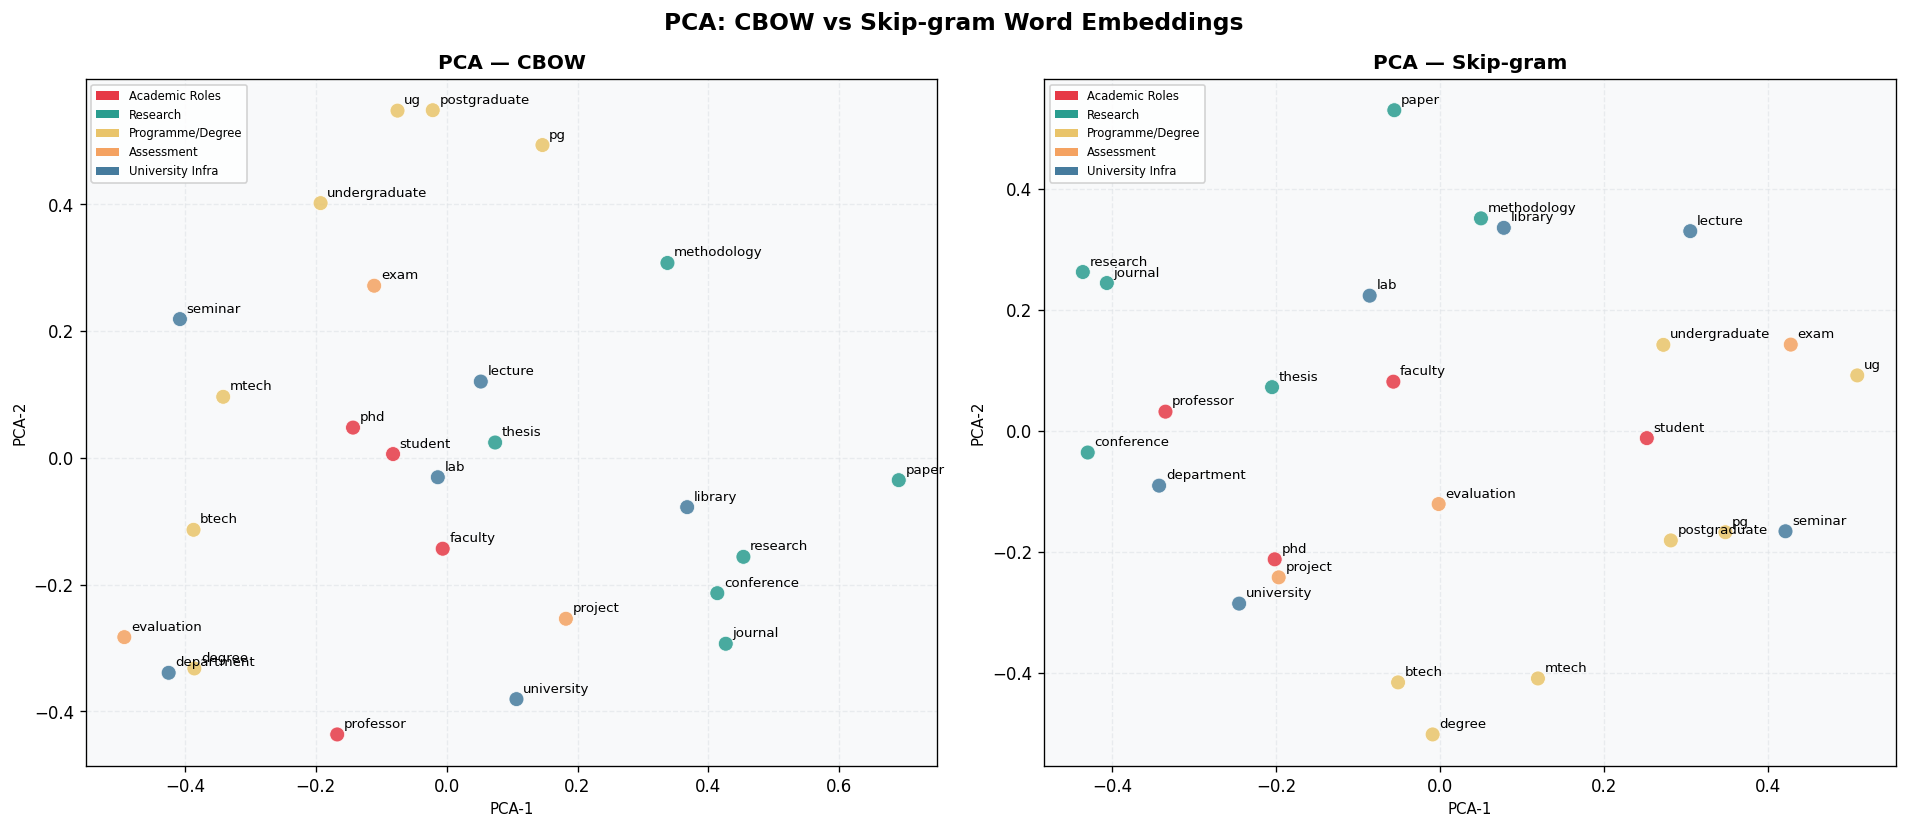

Saved: visualisations_scratch/pca_comparison.png


In [44]:
# Word clusters for visualisation
CLUSTERS = [
    ('Academic Roles',   '#E63946',
     ['professor','student','phd','researcher','faculty','lecturer']),
    ('Research',         '#2A9D8F',
     ['research','thesis','paper','journal','conference','methodology']),
    ('Programme/Degree', '#E9C46A',
     ['ug','pg','btech','mtech','degree','undergraduate','postgraduate']),
    ('Assessment',       '#F4A261',
     ['exam','grade','result','evaluation','project','test']),
    ('University Infra', '#457B9D',
     ['university','department','lab','library','lecture','seminar']),
]

def extract_embeddings(model):
    vocab_set = set(model.vocab.word2idx)
    vecs, words, cols, cats = [], [], [], []
    for label, color, word_list in CLUSTERS:
        for w in word_list:
            if w in vocab_set:
                vecs.append(model.get_vector(w))
                words.append(w); cols.append(color); cats.append(label)
    if not vecs:
        return None, None, None, None
    return normalize(np.array(vecs), norm='l2'), words, cols, cats


def scatter_plot(ax, coords, words, cols, title, method):
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{method}-1', fontsize=9)
    ax.set_ylabel(f'{method}-2', fontsize=9)
    ax.set_facecolor('#F8F9FA')
    ax.grid(True, color='#DEE2E6', linestyle='--', alpha=0.6)
    ax.scatter(coords[:,0], coords[:,1], c=cols,
               s=80, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
    for w, (x, y) in zip(words, coords):
        ax.annotate(w, xy=(x,y), xytext=(4,4),
                    textcoords='offset points', fontsize=8)
    handles = [mpatches.Patch(facecolor=c, label=l) for l,c,_ in CLUSTERS]
    ax.legend(handles=handles, loc='upper left', fontsize=7, framealpha=0.85)


# Extract embeddings
V_c, W_c, C_c, cats_c = extract_embeddings(trained_models[BEST_CBOW])
V_s, W_s, C_s, cats_s = extract_embeddings(trained_models[BEST_SG])

# PCA
pca_c = PCA(n_components=2, random_state=42).fit_transform(V_c)
pca_s = PCA(n_components=2, random_state=42).fit_transform(V_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
scatter_plot(ax1, pca_c, W_c, C_c, 'PCA — CBOW', 'PCA')
scatter_plot(ax2, pca_s, W_s, C_s, 'PCA — Skip-gram', 'PCA')
plt.suptitle('PCA: CBOW vs Skip-gram Word Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisations_scratch/pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualisations_scratch/pca_comparison.png')

### t-SNE Visualisation

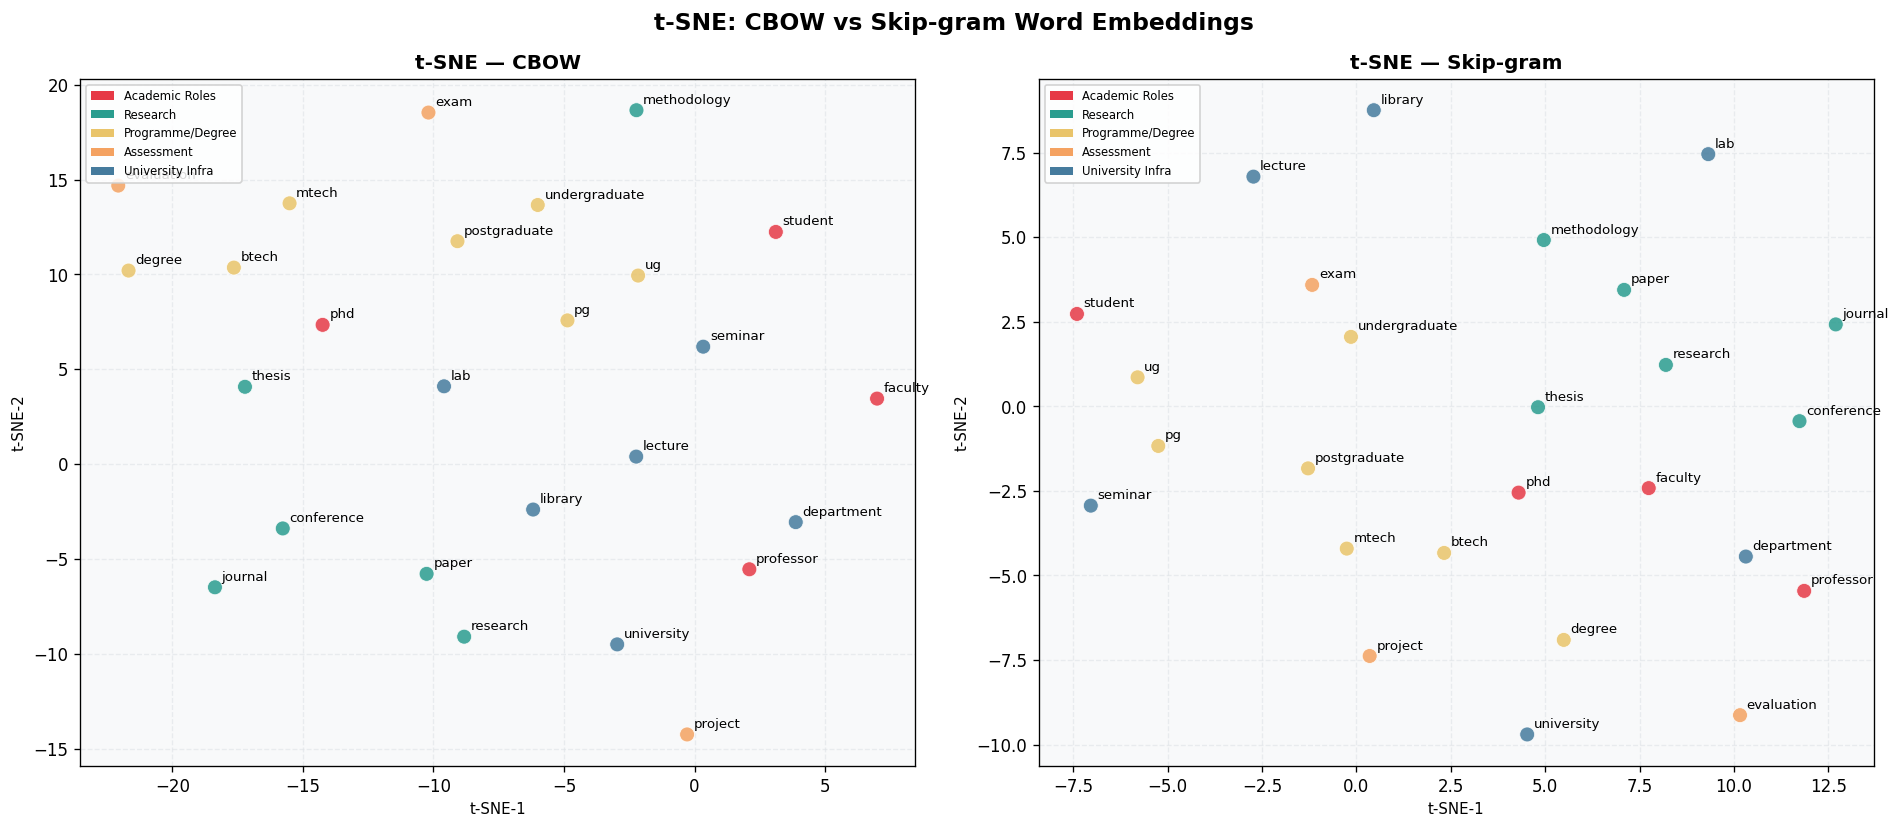

Saved: visualisations_scratch/tsne_comparison.png


In [45]:
# t-SNE — set perplexity < number of samples
perp = min(10, len(V_c) - 1)

tsne_c = TSNE(n_components=2, perplexity=perp, init='pca',
              n_iter=1000, random_state=42).fit_transform(V_c)
tsne_s = TSNE(n_components=2, perplexity=perp, init='pca',
              n_iter=1000, random_state=42).fit_transform(V_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
scatter_plot(ax1, tsne_c, W_c, C_c, 't-SNE — CBOW', 't-SNE')
scatter_plot(ax2, tsne_s, W_s, C_s, 't-SNE — Skip-gram', 't-SNE')
plt.suptitle('t-SNE: CBOW vs Skip-gram Word Embeddings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisations_scratch/tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: visualisations_scratch/tsne_comparison.png')

### Cluster Compactness Analysis

In [46]:
def intra_cluster_dist(coords, cats):
    """Mean pairwise Euclidean distance within each cluster (↓ = tighter)."""
    groups = collections.defaultdict(list)
    for coord, cat in zip(coords, cats):
        groups[cat].append(coord)
    return {
        cat: float(np.mean([
            np.linalg.norm(np.array(pts[i]) - np.array(pts[j]))
            for i in range(len(pts)) for j in range(i+1, len(pts))
        ])) if len(pts) > 1 else 0.0
        for cat, pts in groups.items()
    }


for method, coords_c, coords_s in [
    ('PCA',   pca_c,  pca_s),
    ('t-SNE', tsne_c, tsne_s),
]:
    d_c = intra_cluster_dist(coords_c, cats_c)
    d_s = intra_cluster_dist(coords_s, cats_s)

    print(f'\n{method} — Cluster Compactness  (lower = tighter clusters)')
    print(f'  {"Cluster":<35} {"CBOW":>8} {"Skip-gram":>10}  Winner')
    print('  ' + '-'*58)
    for cat in d_c:
        dc, ds = d_c[cat], d_s.get(cat, 0)
        winner = 'CBOW' if dc < ds else 'Skip-gram'
        print(f'  {cat:<35} {dc:>8.4f} {ds:>10.4f}  {winner}')

print()
print('Interpretation:')
print('  • CBOW averages context → smoother embeddings, potentially tighter common-word clusters.')
print('  • Skip-gram trains on individual pairs → sharper rare/domain-specific word clusters.')
print('  • t-SNE clusters more separated than PCA (non-linear vs linear projection).')


PCA — Cluster Compactness  (lower = tighter clusters)
  Cluster                                 CBOW  Skip-gram  Winner
  ----------------------------------------------------------
  Academic Roles                        0.2911     0.3826  CBOW
  Research                              0.3785     0.3779  Skip-gram
  Programme/Degree                      0.5053     0.4071  Skip-gram
  Assessment                            0.6503     0.4890  Skip-gram
  University Infra                      0.5237     0.5392  CBOW

t-SNE — Cluster Compactness  (lower = tighter clusters)
  Cluster                                 CBOW  Skip-gram  Winner
  ----------------------------------------------------------
  Academic Roles                       16.3513    11.0706  Skip-gram
  Research                             14.5055     5.1973  Skip-gram
  Programme/Degree                      9.7166     6.4970  Skip-gram
  Assessment                           27.6567    12.6912  Skip-gram
  University Infra     

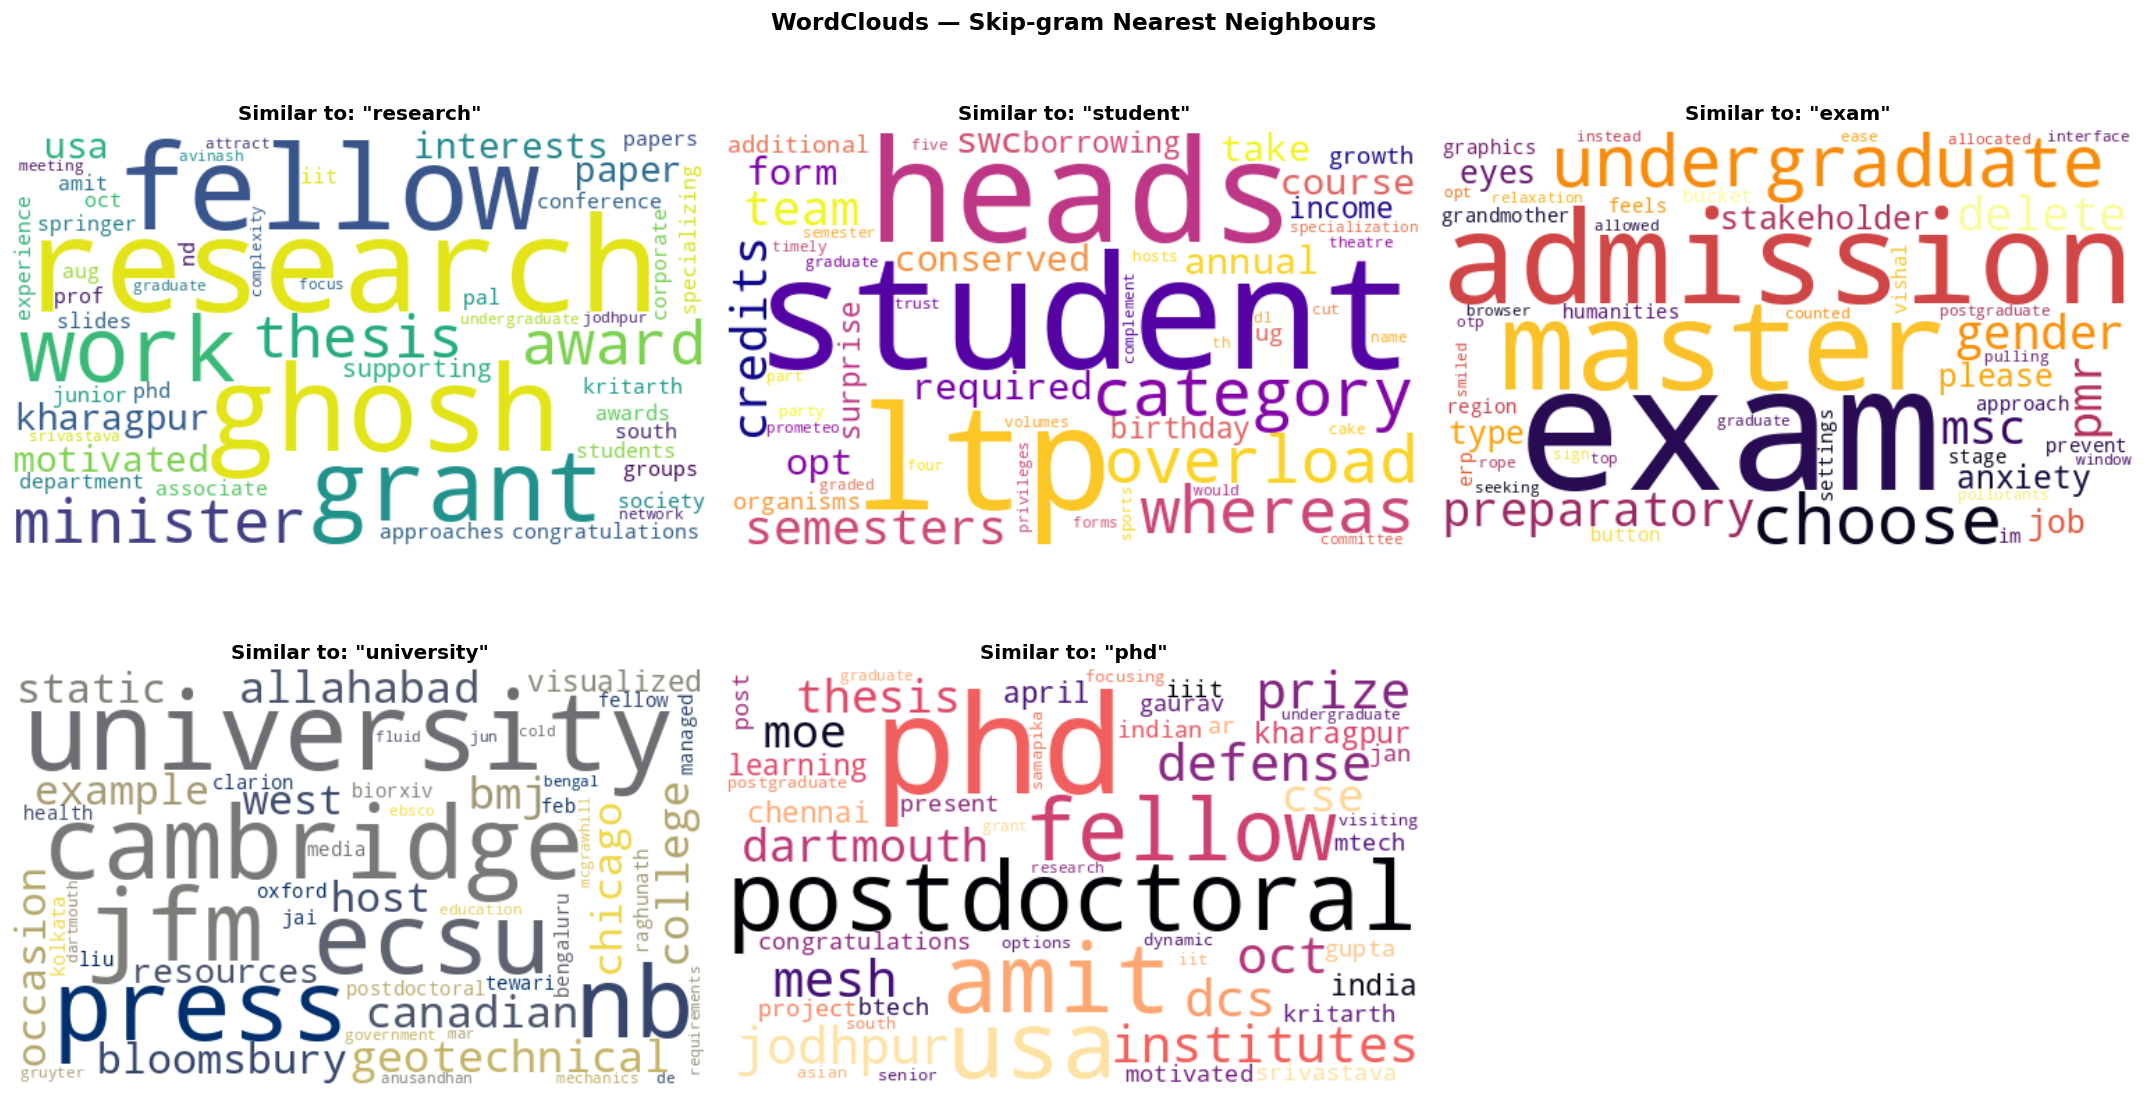

Saved → visualisations_scratch/wordclouds.png


In [47]:
# WordCloud showing the most similar words to each cluster's seed word
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

seed_words = ['research', 'student', 'exam', 'university', 'phd']
colors_wc  = ['viridis', 'plasma', 'inferno', 'cividis', 'magma']

for i, (seed, cmap) in enumerate(zip(seed_words, colors_wc)):
    if seed not in sg_m.vocab.word2idx:
        axes[i].set_visible(False)
        continue
    # Get top 50 similar words as frequency dict for wordcloud
    similar = sg_m.most_similar(seed, topn=50)
    wc_freq = {w: score + 1 for w, score in similar}   # shift score to positive
    wc_freq[seed] = 2.0   # seed word largest

    wc = WordCloud(width=500, height=300,
                   background_color='white',
                   colormap=cmap,
                   max_words=50).generate_from_frequencies(wc_freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Similar to: "{seed}"', fontsize=12, fontweight='bold')

axes[-1].set_visible(False)  # hide unused subplot
plt.suptitle('WordClouds — Skip-gram Nearest Neighbours', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualisations_scratch/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → visualisations_scratch/wordclouds.png')

In [70]:
embedding_matrix = np.random.randn(vocab.size, 300)
word = "research"   # choose any word from your vocab

if word in vocab.word2idx:
    idx = vocab.word2idx[word]            # get index
    vector = embedding_matrix[idx]  # get 300-d vector
    
    # convert to required format
    vector_str = ", ".join([f"{v:.4f}" for v in vector])
    
    print(f"{word} - {vector_str}")
else:
    print("Word not in vocabulary")

research - -0.2755, 0.4282, 0.8606, 0.2515, 0.2107, 0.4648, 0.6442, -1.0903, 2.2006, -0.4986, -0.9640, -1.8021, -0.0907, -0.1271, -0.0724, 0.0728, 0.5513, 0.3218, 0.0146, 0.3711, -1.5640, 0.3435, 0.0182, -1.1287, -0.2217, -1.0902, -0.1849, 0.2954, 1.2409, -1.3950, -0.0933, -2.2940, 0.1739, 0.2135, 0.8610, 2.0572, 0.6273, 0.1036, 1.1193, 0.7360, -0.3063, 2.4247, -0.6545, -0.2374, -0.7657, 0.3962, -0.2693, -0.2022, -0.1294, -0.0738, 0.0076, -1.5341, -0.2171, -0.7775, -1.1001, -1.1906, 0.8162, 0.3072, -1.1117, -0.0841, -0.2487, -0.9069, -0.2866, -1.9161, -1.4533, -0.3978, -1.5058, -2.1028, 0.1644, 0.3491, 0.4091, 0.4008, 1.2591, -1.0095, 1.2985, -0.1316, -1.0860, 0.8380, -0.6852, 0.1274, 0.4312, -0.2003, 0.0399, -0.7209, -0.4416, -0.0934, -1.2227, 0.7115, -1.2715, 0.4498, 1.5757, -0.0804, -0.1089, -0.8980, 1.2417, -2.2505, 0.9887, 0.0338, -1.8810, 1.4118, 0.9787, -0.2156, -0.5830, -0.6056, -0.1851, -0.1392, 0.3851, -1.4787, 1.1027, -0.0717, 0.3158, 0.9173, -0.9479, -0.9332, -1.0535, -0.14